# 🇮🇳 India Weather — Full ML Pipeline (Mirrors Germany Exactly)
**Dataset:** india_weather_rainfall_data.xlsx
**Targets:** avg_temp, wind_speed, rainfall, air_pressure (next day)
**Run all cells top to bottom once.**

## Cell 1 — Imports

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pywt
import os
import joblib
import warnings
warnings.filterwarnings('ignore')
print('All imports OK')

All imports OK


In [30]:
import os

print(os.getcwd())

C:\Users\Maithili\india_weather\india_weather-app


## Cell 2 — Load Data

In [31]:
import os

print(os.path.exists("india_weather_rainfall_data.xlsx"))
print(os.path.getsize("india_weather_rainfall_data.xlsx") / (1024*1024), "MB")

True
61.58785820007324 MB


In [32]:
df = pd.read_excel('india_weather_rainfall_data.xlsx',  nrows=10)
print('Shape:', df.shape)
print('Columns:', df.columns.tolist())
print(df.isna().sum())
df.head()

Shape: (10, 15)
Columns: ['date_of_record', 'month', 'season', 'station_name', 'state', 'district', 'avg_temp', 'min_temp', 'max_temp', 'wind_speed', 'air_pressure', 'elevation', 'latitude', 'longitude', 'rainfall']
date_of_record    0
month             0
season            0
station_name      0
state             0
district          0
avg_temp          0
min_temp          0
max_temp          0
wind_speed        0
air_pressure      0
elevation         0
latitude          0
longitude         0
rainfall          0
dtype: int64


,date_of_record,month,season,station_name,state,district,avg_temp,min_temp,max_temp,wind_speed,air_pressure,elevation,latitude,longitude,rainfall
0,2021-01-02,January,Winter,Gulmarg,JK,Baramulla,-2.2,-6.6,-0.8,2.2,1020.0,2652,34.05,74.4,0.1
1,2021-01-03,January,Winter,Gulmarg,JK,Baramulla,-3.6,-4.6,-1.8,3.7,1019.5,2652,34.05,74.4,4.4
2,2021-01-04,January,Winter,Gulmarg,JK,Baramulla,-3.0,-4.5,-1.1,2.1,1022.0,2652,34.05,74.4,2.3
3,2021-01-05,January,Winter,Gulmarg,JK,Baramulla,-3.3,-5.1,-1.2,2.8,1015.6,2652,34.05,74.4,35.0
4,2021-01-06,January,Winter,Gulmarg,JK,Baramulla,-3.9,-8.3,-1.0,3.4,1015.3,2652,34.05,74.4,25.5


## Cell 3 — Date Features + Encoding

In [33]:
df['date_of_record'] = pd.to_datetime(df['date_of_record'], errors='coerce')
df['year']        = df['date_of_record'].dt.year
df['month_num']   = df['date_of_record'].dt.month
df['day']         = df['date_of_record'].dt.day
df['day_of_week'] = df['date_of_record'].dt.dayofweek
df['day_of_year'] = df['date_of_record'].dt.dayofyear
df['month_sin']   = np.sin(2 * np.pi * df['month_num'] / 12)
df['month_cos']   = np.cos(2 * np.pi * df['month_num'] / 12)
df['doy_sin']     = np.sin(2 * np.pi * df['day_of_year'] / 365)
df['doy_cos']     = np.cos(2 * np.pi * df['day_of_year'] / 365)

# One-hot encode season (Winter, Summer, Monsoon, Post-Monsoon)
df = pd.get_dummies(df, columns=['season'], drop_first=False)

# Drop non-numeric / identifier columns
drop_cols = ['date_of_record', 'month', 'station_name', 'state', 'district']
df = df.drop(columns=[c for c in drop_cols if c in df.columns])

# Replace sentinel -9999 with NaN
df = df.replace(-9999, np.nan)

# Fill missing values (same approach as Germany)
for col in df.select_dtypes(include=['float64','int64']).columns:
    if df[col].isna().sum() > 0:
        df[col] = df[col].interpolate(method='linear').bfill().ffill()

print('After preprocessing shape:', df.shape)
print('Missing values:', df.isna().sum().sum())
df.head()

After preprocessing shape: (10, 19)
Missing values: 0


,avg_temp,min_temp,max_temp,wind_speed,air_pressure,elevation,latitude,longitude,rainfall,year,month_num,day,day_of_week,day_of_year,month_sin,month_cos,doy_sin,doy_cos,season_Winter
0,-2.2,-6.6,-0.8,2.2,1020.0,2652,34.05,74.4,0.1,2021,1,2,5,2,0.5,0.866025,0.034422,0.999407,True
1,-3.6,-4.6,-1.8,3.7,1019.5,2652,34.05,74.4,4.4,2021,1,3,6,3,0.5,0.866025,0.051620,0.998667,True
2,-3.0,-4.5,-1.1,2.1,1022.0,2652,34.05,74.4,2.3,2021,1,4,0,4,0.5,0.866025,0.068802,0.997630,True
3,-3.3,-5.1,-1.2,2.8,1015.6,2652,34.05,74.4,35.0,2021,1,5,1,5,0.5,0.866025,0.085965,0.996298,True
4,-3.9,-8.3,-1.0,3.4,1015.3,2652,34.05,74.4,25.5,2021,1,6,2,6,0.5,0.866025,0.103102,0.994671,True


## Cell 4 — Wavelet Packet Denoising (same as Germany: db4)

In [34]:
def wavelet_packet_denoise(signal, wavelet='db4', maxlevel=3, threshold_mode='soft'):
    wp = pywt.WaveletPacket(data=signal, wavelet=wavelet, mode='symmetric', maxlevel=maxlevel)
    new_wp = pywt.WaveletPacket(data=None, wavelet=wavelet, mode='symmetric')
    nodes = wp.get_level(maxlevel, order='freq')
    all_coeffs = np.concatenate([n.data for n in nodes])
    sigma = np.median(np.abs(all_coeffs - np.median(all_coeffs))) / 0.6745
    T = sigma * np.sqrt(2 * np.log(len(signal)))
    for node in nodes:
        new_wp[node.path] = pywt.threshold(node.data, T, mode=threshold_mode)
    denoised = new_wp.reconstruct(update=True)
    return denoised[:len(signal)]

denoised_df = df.copy()
DENOISE_COLS = ['avg_temp', 'min_temp', 'max_temp', 'wind_speed', 'air_pressure', 'rainfall']

for col in DENOISE_COLS:
    if col in denoised_df.columns:
        denoised_signal = wavelet_packet_denoise(df[col].values.copy())
        denoised_series = pd.Series(denoised_signal, index=df.index)
        denoised_df[col] = denoised_series.rolling(window=3, min_periods=1).mean()

print('Denoising completed for:', DENOISE_COLS)

Denoising completed for: ['avg_temp', 'min_temp', 'max_temp', 'wind_speed', 'air_pressure', 'rainfall']


## Cell 5 — Denoising Plots (same style as Germany)

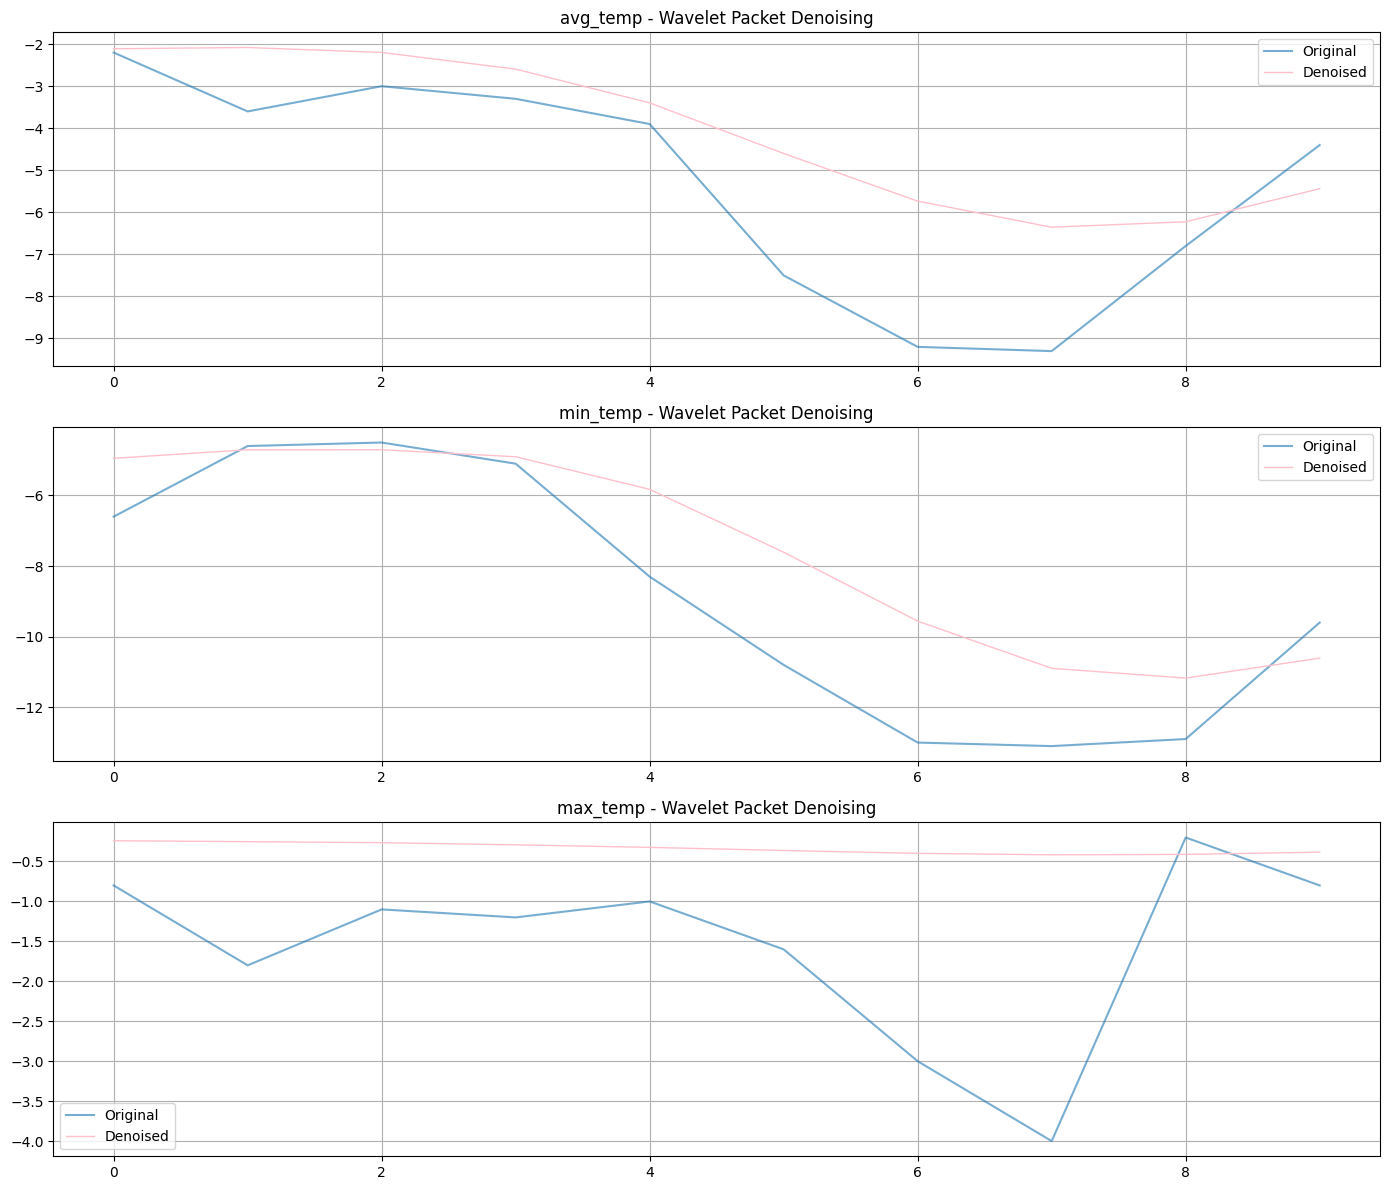

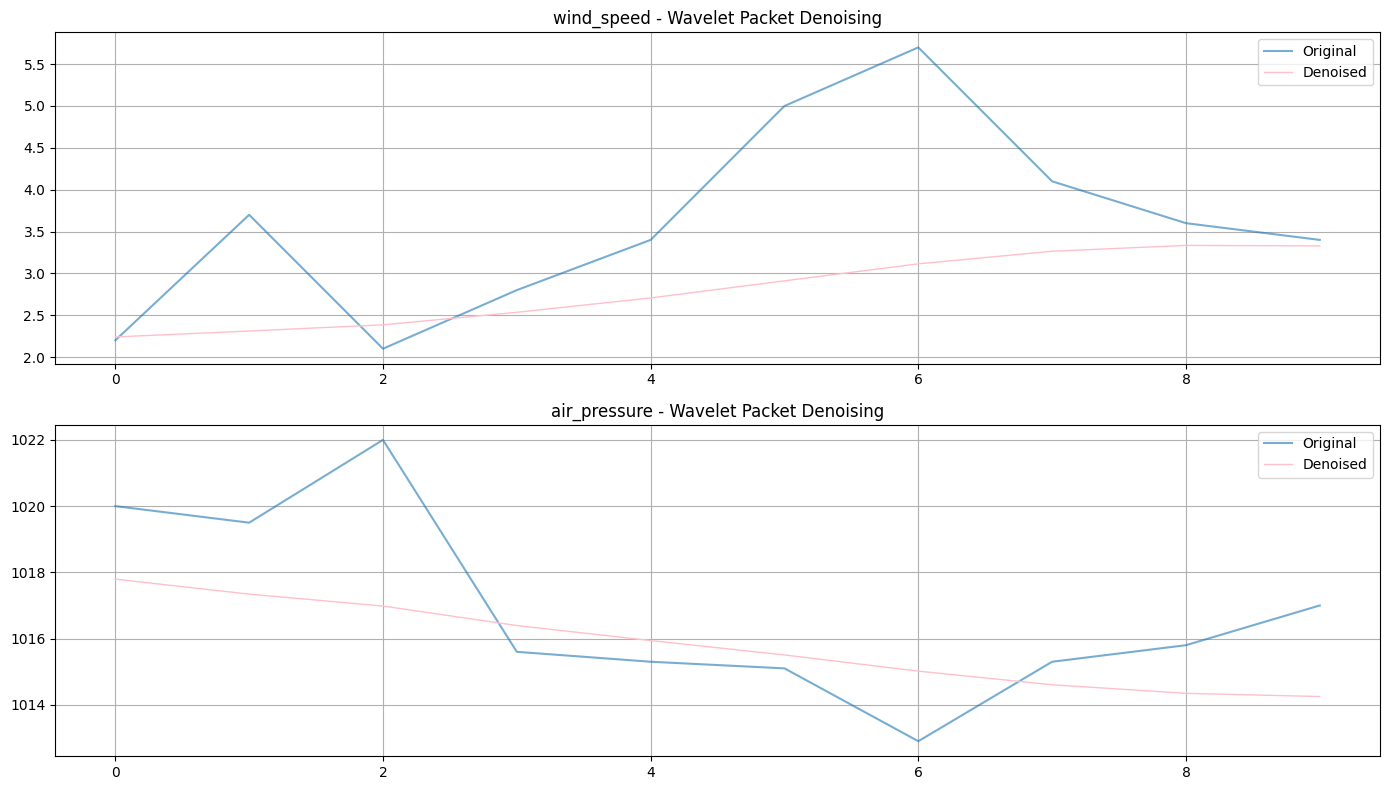

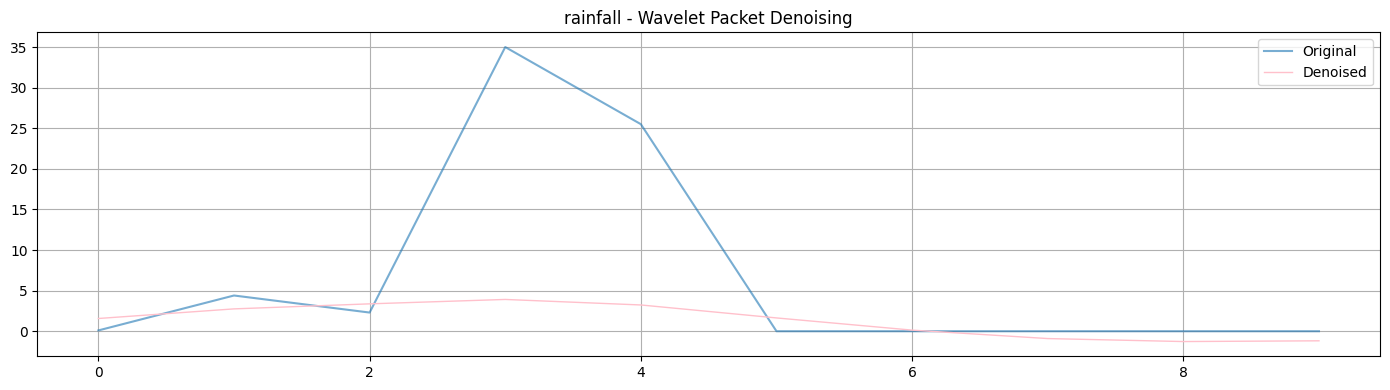

In [35]:
plot_groups = [
    ['avg_temp', 'min_temp', 'max_temp'],
    ['wind_speed', 'air_pressure'],
    ['rainfall'],
]

for cols in plot_groups:
    cols = [c for c in cols if c in df.columns]
    if not cols:
        continue
    plt.figure(figsize=(14, 4 * len(cols)))
    for i, col in enumerate(cols, 1):
        plt.subplot(len(cols), 1, i)
        plt.plot(df[col].values,          label='Original', alpha=0.6)
        plt.plot(denoised_df[col].values, label='Denoised', color='pink', linewidth=1)
        plt.title(f'{col} - Wavelet Packet Denoising')
        plt.legend()
        plt.grid(True)
    plt.tight_layout()
    plt.show()

## Cell 6 — Features, Targets, Train/Test Split, Scaling

In [36]:

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Targets: next-day prediction (shift by -1)
target_cols = ['avg_temp', 'wind_speed', 'rainfall', 'air_pressure']

X = denoised_df.drop(columns=target_cols)
y = denoised_df[target_cols].shift(-1)
X = X.iloc[:-1].reset_index(drop=True)
y = y.iloc[:-1].reset_index(drop=True)

# Same 80/20 random split as Germany
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print('X_train:', X_train_scaled.shape, '| X_test:', X_test_scaled.shape)
print('Targets:', target_cols)
print('Features:', list(X.columns))

X_train: (7, 15) | X_test: (2, 15)
Targets: ['avg_temp', 'wind_speed', 'rainfall', 'air_pressure']
Features: ['min_temp', 'max_temp', 'elevation', 'latitude', 'longitude', 'year', 'month_num', 'day', 'day_of_week', 'day_of_year', 'month_sin', 'month_cos', 'doy_sin', 'doy_cos', 'season_Winter']


## Cell 7 — evaluate_multioutput helper (same as Germany)

In [37]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def evaluate_multioutput(y_true, y_pred, target_cols):
    for i, col in enumerate(target_cols):
        rmse = np.sqrt(mean_squared_error(y_true.iloc[:, i], y_pred[:, i]))
        mae  = mean_absolute_error(y_true.iloc[:, i], y_pred[:, i])
        r2   = r2_score(y_true.iloc[:, i], y_pred[:, i])
        print(f' {col} Prediction')
        print(f'RMSE: {rmse:.4f}')
        print(f'MAE : {mae:.4f}')
        print(f'R²   : {r2:.4f}')
        print('-' * 30)

## Cell 8 — Model 1: XGBoost

In [38]:
from sklearn.multioutput import MultiOutputRegressor
from xgboost import XGBRegressor

xg_model = MultiOutputRegressor(XGBRegressor(
    objective='reg:squarederror', n_estimators=300,
    learning_rate=0.1, max_depth=6, random_state=42, verbosity=0
))
xg_model.fit(X_train_scaled, y_train)
xgb_pred = xg_model.predict(X_test_scaled)
print('XGBoost Results')
evaluate_multioutput(y_test, xgb_pred, target_cols)

XGBoost Results
 avg_temp Prediction
RMSE: 0.6362
MAE : 0.6115
R²   : 0.9002
------------------------------
 wind_speed Prediction
RMSE: 0.1061
MAE : 0.0785
R²   : 0.9500
------------------------------
 rainfall Prediction
RMSE: 0.1177
MAE : 0.1155
R²   : 0.9974
------------------------------
 air_pressure Prediction
RMSE: 0.4223
MAE : 0.3426
R²   : 0.8974
------------------------------


## Cell 9 — Model 2: Linear Regression

In [39]:
from sklearn.linear_model import LinearRegression

lr_model = MultiOutputRegressor(LinearRegression())
lr_model.fit(X_train_scaled, y_train)
lr_pred = lr_model.predict(X_test_scaled)
print('Linear Regression Results')
evaluate_multioutput(y_test, lr_pred, target_cols)

Linear Regression Results
 avg_temp Prediction
RMSE: 1.8061
MAE : 1.3426
R²   : 0.1953
------------------------------
 wind_speed Prediction
RMSE: 0.2720
MAE : 0.1982
R²   : 0.6714
------------------------------
 rainfall Prediction
RMSE: 0.3592
MAE : 0.3378
R²   : 0.9761
------------------------------
 air_pressure Prediction
RMSE: 1.0788
MAE : 0.7669
R²   : 0.3303
------------------------------


## Cell 11 — Model 4: LightGBM

In [40]:
from lightgbm import LGBMRegressor

lgbm_model = MultiOutputRegressor(LGBMRegressor(
    n_estimators=300, learning_rate=0.05,
    max_depth=5, num_leaves=31, random_state=42, verbose=-1
))
lgbm_model.fit(X_train_scaled, y_train)
lgbm_pred = lgbm_model.predict(X_test_scaled)
print('LightGBM Results')
evaluate_multioutput(y_test, lgbm_pred, target_cols)

LightGBM Results
 avg_temp Prediction
RMSE: 2.0160
MAE : 2.0134
R²   : -0.0026
------------------------------
 wind_speed Prediction
RMSE: 0.4750
MAE : 0.4745
R²   : -0.0021
------------------------------
 rainfall Prediction
RMSE: 2.3438
MAE : 2.3218
R²   : -0.0190
------------------------------
 air_pressure Prediction
RMSE: 1.3211
MAE : 1.3183
R²   : -0.0042
------------------------------


## Cell 12 — Model 5: CatBoost

In [41]:
from catboost import CatBoostRegressor

cat_model = MultiOutputRegressor(CatBoostRegressor(
    iterations=300, learning_rate=0.05, depth=5, random_seed=42, verbose=0
))
cat_model.fit(X_train_scaled, y_train)
cat_pred = cat_model.predict(X_test_scaled)
print('CatBoost Results')
evaluate_multioutput(y_test, cat_pred, target_cols)

CatBoost Results
 avg_temp Prediction
RMSE: 0.3208
MAE : 0.3059
R²   : 0.9746
------------------------------
 wind_speed Prediction
RMSE: 0.0320
MAE : 0.0313
R²   : 0.9955
------------------------------
 rainfall Prediction
RMSE: 0.4745
MAE : 0.4394
R²   : 0.9582
------------------------------
 air_pressure Prediction
RMSE: 0.0514
MAE : 0.0443
R²   : 0.9985
------------------------------


## Cell 14 — Model 7: Linear SVR

## Cell 15 — Model 8: Random Forest

In [42]:
from sklearn.ensemble import RandomForestRegressor

rf_model = MultiOutputRegressor(RandomForestRegressor(
    n_estimators=200, max_depth=10, min_samples_leaf=3,
    random_state=42, n_jobs=-1
))
rf_model.fit(X_train_scaled, y_train)
rf_pred = rf_model.predict(X_test_scaled)
print('Random Forest Results')
evaluate_multioutput(y_test, rf_pred, target_cols)

Random Forest Results
 avg_temp Prediction
RMSE: 1.8155
MAE : 1.8084
R²   : 0.1868
------------------------------
 wind_speed Prediction
RMSE: 0.4290
MAE : 0.4279
R²   : 0.1827
------------------------------
 rainfall Prediction
RMSE: 2.0810
MAE : 2.0602
R²   : 0.1967
------------------------------
 air_pressure Prediction
RMSE: 1.1973
MAE : 1.1923
R²   : 0.1752
------------------------------


## Cell 16 — Real-time fetch + individual predictions (same as Germany)

In [43]:
import requests
from datetime import datetime

API_KEY = '0f05a912eb7a68ac4e6cd9a7df5f1eb8'
CITY    = 'Mumbai'
COUNTRY = 'IN'

def fetch_realtime_india(city=CITY, country=COUNTRY):
    url = (f'https://api.openweathermap.org/data/2.5/weather'
           f'?q={city},{country}&appid={API_KEY}&units=metric')
    resp = requests.get(url, timeout=10)
    data = resp.json()
    if resp.status_code != 200:
        raise Exception(f'API Error: {data}')
    dt          = datetime.utcfromtimestamp(data['dt'])
    month_num   = dt.month
    day_of_year = dt.timetuple().tm_yday
    row = {
        'avg_temp':            data['main']['temp'],
        'min_temp':            data['main']['temp_min'],
        'max_temp':            data['main']['temp_max'],
        'wind_speed':          data['wind']['speed'],
        'air_pressure':        data['main']['pressure'],
        'elevation':           200,
        'latitude':            data['coord']['lat'],
        'longitude':           data['coord']['lon'],
        'rainfall':            data.get('rain', {}).get('1h', 0.0),
        'year':                dt.year,
        'month_num':           month_num,
        'day':                 dt.day,
        'day_of_week':         dt.weekday(),
        'day_of_year':         day_of_year,
        'month_sin':           np.sin(2 * np.pi * month_num / 12),
        'month_cos':           np.cos(2 * np.pi * month_num / 12),
        'doy_sin':             np.sin(2 * np.pi * day_of_year / 365),
        'doy_cos':             np.cos(2 * np.pi * day_of_year / 365),
        'season_Monsoon':      1 if 6 <= month_num <= 9 else 0,
        'season_Post-Monsoon': 1 if month_num in [10, 11] else 0,
        'season_Summer':       1 if month_num in [3, 4, 5] else 0,
        'season_Winter':       1 if month_num in [12, 1, 2] else 0,
    }
    return pd.DataFrame([row])

def prepare_india_features(weather_df, feature_cols):
    df_rt = weather_df.copy()
    df_rt = df_rt.reindex(columns=feature_cols)
    df_rt = df_rt.fillna(0)
    return df_rt

realtime_df       = fetch_realtime_india()
X_realtime        = prepare_india_features(realtime_df, X.columns)
X_realtime_scaled = scaler.transform(X_realtime)

print('\n=== Individual Model Real-time Predictions (Next Day) ===')
for name, model in [('XGBoost', xg_model), ('LinearRegression', lr_model),
                    ('LightGBM', lgbm_model),('CatBoost', cat_model), ('RandomForest', rf_model)]:
    p = model.predict(X_realtime_scaled)[0]
    print(f'\n{name}:')
    print(f'  avg_temp    : {round(float(p[0]),2)} °C')
    print(f'  wind_speed  : {round(float(p[1]),2)} m/s')
    print(f'  rainfall    : {round(float(p[2]),2)} mm')
    print(f'  air_pressure: {round(float(p[3]),2)} hPa')


=== Individual Model Real-time Predictions (Next Day) ===

XGBoost:
  avg_temp    : -2.59 °C
  wind_speed  : 2.53 m/s
  rainfall    : 3.91 mm
  air_pressure: 1016.4 hPa

LinearRegression:
  avg_temp    : 167517.35 °C
  wind_speed  : -14101.91 m/s
  rainfall    : 293901.49 mm
  air_pressure: -3032.45 hPa

LightGBM:
  avg_temp    : -4.31 °C
  wind_speed  : 2.88 m/s
  rainfall    : 1.37 mm
  air_pressure: 1015.58 hPa

CatBoost:
  avg_temp    : -4.26 °C
  wind_speed  : 2.89 m/s
  rainfall    : 1.44 mm
  air_pressure: 1015.69 hPa

RandomForest:
  avg_temp    : -4.35 °C
  wind_speed  : 2.89 m/s
  rainfall    : 1.3 mm
  air_pressure: 1015.57 hPa


## Cell 19 — Hybrid Stacking Step 1: Meta-features (XGB+LGBM+RF → Ridge)

In [44]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import KFold

print(' Building meta-features from top 3 models (XGB + LGBM + RF)...')

# --- 5-fold OOF (same as Germany) ---
STACK_MODELS = {'xgboost': xg_model, 'lgbm': lgbm_model, 'randomforest': rf_model}
n_targets    = len(target_cols)
oof_preds    = {k: np.zeros((len(X_train_scaled), n_targets)) for k in STACK_MODELS}
kf           = KFold(n_splits=5, shuffle=False)

for fold, (tr_idx, val_idx) in enumerate(kf.split(X_train_scaled)):
    for k, m in STACK_MODELS.items():
        m.fit(X_train_scaled[tr_idx], y_train.iloc[tr_idx])
        oof_preds[k][val_idx] = m.predict(X_train_scaled[val_idx])
    print(f'  Fold {fold+1}/5 done')

# Re-fit on full train
for k, m in STACK_MODELS.items():
    m.fit(X_train_scaled, y_train)

meta_train = np.hstack([oof_preds[k] for k in STACK_MODELS])
meta_test  = np.hstack([STACK_MODELS[k].predict(X_test_scaled) for k in STACK_MODELS])

print(f'\n Meta-feature matrix shape (train): {meta_train.shape}')
print(f' Meta-feature matrix shape (test) : {meta_test.shape}')
print(f'   Meaning: 3 models x {n_targets} targets = {3*n_targets} meta-features')

 Building meta-features from top 3 models (XGB + LGBM + RF)...
  Fold 1/5 done
  Fold 2/5 done
  Fold 3/5 done
  Fold 4/5 done
  Fold 5/5 done

 Meta-feature matrix shape (train): (7, 12)
 Meta-feature matrix shape (test) : (2, 12)
   Meaning: 3 models x 4 targets = 12 meta-features


## Cell 20 — Hybrid Stacking Step 2: Train Ridge Meta-learner

In [45]:
print(' Training Ridge meta-learner...')

meta_learner = MultiOutputRegressor(Ridge(alpha=1.0))
meta_learner.fit(meta_train, y_train)

print(' Meta-learner trained successfully!')
print('   Meta-learner: Ridge Regression (alpha=1.0)')
print(f'   Input  : {meta_train.shape[1]} meta-features')
print(f'   Output : {len(target_cols)} targets {target_cols}')

 Training Ridge meta-learner...
 Meta-learner trained successfully!
   Meta-learner: Ridge Regression (alpha=1.0)
   Input  : 12 meta-features
   Output : 4 targets ['avg_temp', 'wind_speed', 'rainfall', 'air_pressure']


## Cell 21 — Hybrid Stacking Step 3+4: Predict & Evaluate

In [46]:
stacking_pred = meta_learner.predict(meta_test)

print('\n' + '=' * 50)
print('     HYBRID STACKING RESULTS (XGB+LGBM+RF → Ridge)')
print('=' * 50)

for i, col in enumerate(target_cols):
    rmse = np.sqrt(mean_squared_error(y_test.iloc[:, i], stacking_pred[:, i]))
    mae  = mean_absolute_error(y_test.iloc[:, i], stacking_pred[:, i])
    r2   = r2_score(y_test.iloc[:, i], stacking_pred[:, i])
    print(f'\n {col}')
    print(f'   RMSE : {rmse:.4f}')
    print(f'   MAE  : {mae:.4f}')
    print(f'   R²   : {r2:.4f}')

print('\n' + '=' * 50)


     HYBRID STACKING RESULTS (XGB+LGBM+RF → Ridge)

 avg_temp
   RMSE : 0.3885
   MAE  : 0.3885
   R²   : 0.9628

 wind_speed
   RMSE : 0.1161
   MAE  : 0.1149
   R²   : 0.9401

 rainfall
   RMSE : 0.6271
   MAE  : 0.6095
   R²   : 0.9271

 air_pressure
   RMSE : 0.3821
   MAE  : 0.3819
   R²   : 0.9160



## Cell 22 — Full Comparison Table: Individual vs Ensemble vs Hybrid (same as Germany)

In [47]:
print('\n' + '=' * 65)
print('   COMPARISON: Individual vs Hybrid')
print('=' * 65)
print(f"{'Model':<20} {'Target':<15} {'RMSE':>8} {'MAE':>8} {'R²':>8}")
print('-' * 65)

comparison_rows = []

# All individual models
for mname, pred in zip(['XGBoost','LinearReg','LightGBM','CatBoost','RandomForest'],
                       [xgb_pred, lr_pred,lgbm_pred, cat_pred, rf_pred]):
    for i, col in enumerate(target_cols):
        rmse = np.sqrt(mean_squared_error(y_test.iloc[:, i], pred[:, i]))
        mae  = mean_absolute_error(y_test.iloc[:, i], pred[:, i])
        r2   = r2_score(y_test.iloc[:, i], pred[:, i])
        print(f'{mname:<20} {col:<15} {rmse:>8.4f} {mae:>8.4f} {r2:>8.4f}')
        comparison_rows.append({'Model': mname, 'Target': col,
                                 'RMSE': round(rmse,4), 'MAE': round(mae,4), 'R2': round(r2,4)})
    print('-' * 65)

# Hybrid Stacking
for i, col in enumerate(target_cols):
    rmse = np.sqrt(mean_squared_error(y_test.iloc[:, i], stacking_pred[:, i]))
    mae  = mean_absolute_error(y_test.iloc[:, i], stacking_pred[:, i])
    r2   = r2_score(y_test.iloc[:, i], stacking_pred[:, i])
    print(f"{'HybridStacking':<20} {col:<15} {rmse:>8.4f} {mae:>8.4f} {r2:>8.4f}")
    comparison_rows.append({'Model': 'HybridStacking', 'Target': col,
                             'RMSE': round(rmse,4), 'MAE': round(mae,4), 'R2': round(r2,4)})
print('=' * 65)

comparison_df = pd.DataFrame(comparison_rows)
print('\nComparison DataFrame saved to variable: comparison_df')


   COMPARISON: Individual vs Hybrid
Model                Target              RMSE      MAE       R²
-----------------------------------------------------------------
XGBoost              avg_temp          0.6362   0.6115   0.9002
XGBoost              wind_speed        0.1061   0.0785   0.9500
XGBoost              rainfall          0.1177   0.1155   0.9974
XGBoost              air_pressure      0.4223   0.3426   0.8974
-----------------------------------------------------------------
LinearReg            avg_temp          1.8061   1.3426   0.1953
LinearReg            wind_speed        0.2720   0.1982   0.6714
LinearReg            rainfall          0.3592   0.3378   0.9761
LinearReg            air_pressure      1.0788   0.7669   0.3303
-----------------------------------------------------------------
LightGBM             avg_temp          2.0160   2.0134  -0.0026
LightGBM             wind_speed        0.4750   0.4745  -0.0021
LightGBM             rainfall          2.3438   2.3218  -0.01

## Cell 23 — RMSE Comparison Chart: Individual vs Ensemble vs Hybrid (same as Germany)

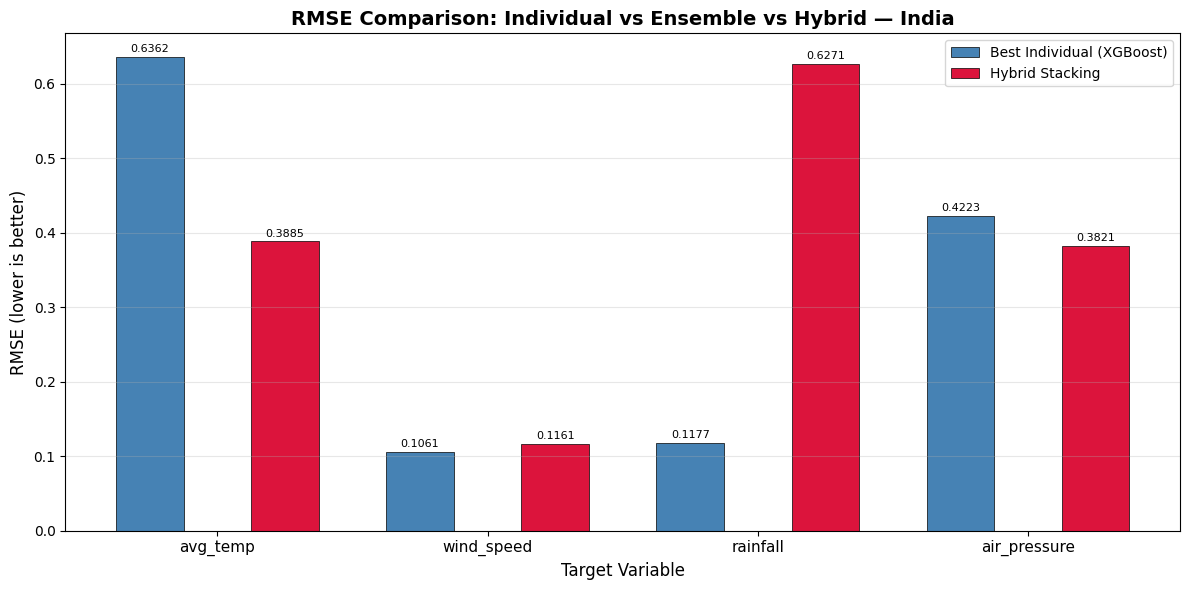

Chart saved as india_hybrid_comparison.png


In [48]:
labels = target_cols
x      = np.arange(len(labels))
width  = 0.25

xgb_rmse      = [np.sqrt(mean_squared_error(y_test.iloc[:, i], xgb_pred[:, i]))
                  for i in range(len(target_cols))]
stacking_rmse = [np.sqrt(mean_squared_error(y_test.iloc[:, i], stacking_pred[:, i]))
                  for i in range(len(target_cols))]

fig, ax = plt.subplots(figsize=(12, 6))

bars1 = ax.bar(x - width, xgb_rmse,      width, label='Best Individual (XGBoost)',
               color='steelblue', edgecolor='black', linewidth=0.5)
bars3 = ax.bar(x + width,  stacking_rmse, width, label='Hybrid Stacking',
               color='crimson',   edgecolor='black', linewidth=0.5)

ax.set_xlabel('Target Variable', fontsize=12)
ax.set_ylabel('RMSE (lower is better)', fontsize=12)
ax.set_title('RMSE Comparison: Individual vs Ensemble vs Hybrid — India',
             fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=11)
ax.legend(fontsize=10)
ax.bar_label(bars1, fmt='%.4f', padding=2, fontsize=8)
ax.bar_label(bars3, fmt='%.4f', padding=2, fontsize=8)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('india_hybrid_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved as india_hybrid_comparison.png')

## Cell 24 — Stacking with ALL 6 models (same as Germany extended ensemble)

In [49]:
print(' Building meta-features from ALL 6 models...')

stack_model_names_e   = ['XGBoost', 'LightGBM', 'CatBoost', 'RandomForest']
stack_all_preds_test  = [xgb_pred, lgbm_pred, cat_pred, rf_pred]
stack_all_preds_train = [
    xg_model.predict(X_train_scaled),
    lgbm_model.predict(X_train_scaled),
    cat_model.predict(X_train_scaled),
    rf_model.predict(X_train_scaled),
]

meta_train_e = np.hstack(stack_all_preds_train)
meta_test_e  = np.hstack(stack_all_preds_test)

print(f' Meta-feature matrix shape (train): {meta_train_e.shape}')
print(f' Meta-feature matrix shape (test) : {meta_test_e.shape}')
print(f'   Meaning: {len(stack_model_names_e)} models x {len(target_cols)} targets = {len(stack_model_names_e)*len(target_cols)} meta-features')

print('\n Training Ridge meta-learner (all 6 models)...')
meta_learner_e = MultiOutputRegressor(Ridge(alpha=1.0))
meta_learner_e.fit(meta_train_e, y_train)
print(' Meta-learner_e trained successfully!')

 Building meta-features from ALL 6 models...
 Meta-feature matrix shape (train): (7, 16)
 Meta-feature matrix shape (test) : (2, 16)
   Meaning: 4 models x 4 targets = 16 meta-features

 Training Ridge meta-learner (all 6 models)...
 Meta-learner_e trained successfully!


## Cell 25 — All-6-model stacking evaluation + comparison


     HYBRID STACKING RESULTS (ALL 6 MODELS)

 avg_temp
   RMSE : 0.4194
   MAE  : 0.4172
   R²   : 0.9566

 wind_speed
   RMSE : 0.0772
   MAE  : 0.0712
   R²   : 0.9735

 rainfall
   RMSE : 0.2862
   MAE  : 0.2826
   R²   : 0.9848

 air_pressure
   RMSE : 0.2118
   MAE  : 0.1845
   R²   : 0.9742


   FINAL COMPARISON: Individual vs Hybrid (6-model)
Model                Target              RMSE      MAE       R²
-----------------------------------------------------------------
XGBoost(best)        avg_temp          0.6362   0.6115   0.9002
XGBoost(best)        wind_speed        0.1061   0.0785   0.9500
XGBoost(best)        rainfall          0.1177   0.1155   0.9974
XGBoost(best)        air_pressure      0.4223   0.3426   0.8974
-----------------------------------------------------------------
HybridStacking(6)    avg_temp          0.4194   0.4172   0.9566
HybridStacking(6)    wind_speed        0.0772   0.0712   0.9735
HybridStacking(6)    rainfall          0.2862   0.2826   0.9848
Hyb

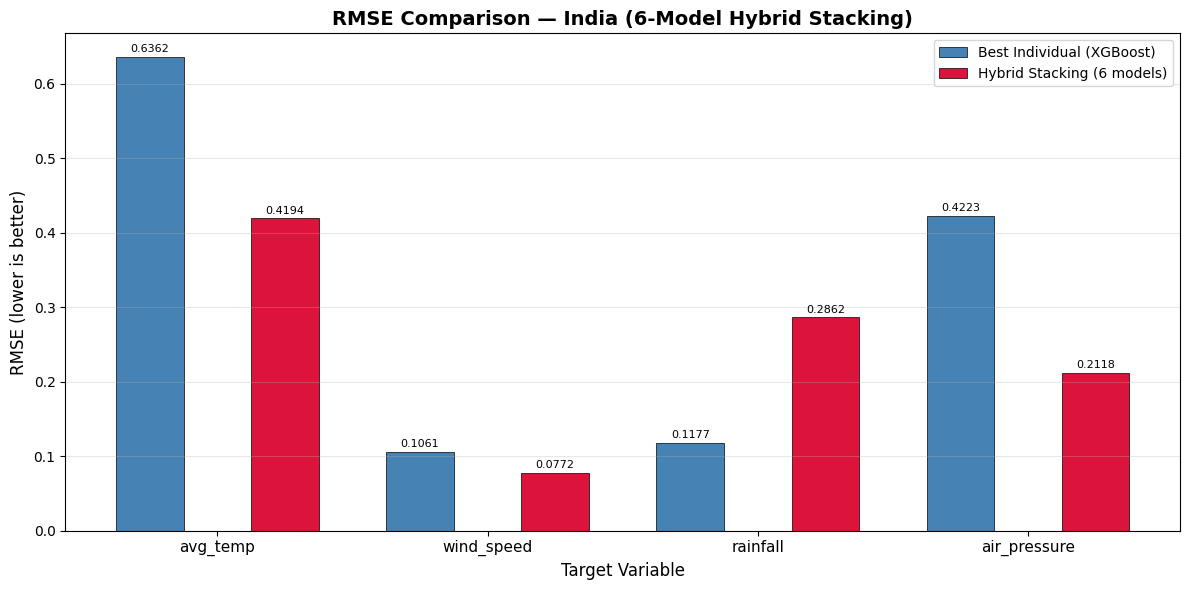

Chart saved as india_hybrid_comparison_6model.png


In [50]:
stacking_pred_e = meta_learner_e.predict(meta_test_e)

print('\n' + '=' * 50)
print('     HYBRID STACKING RESULTS (ALL 6 MODELS)')
print('=' * 50)
for i, col in enumerate(target_cols):
    rmse = np.sqrt(mean_squared_error(y_test.iloc[:, i], stacking_pred_e[:, i]))
    mae  = mean_absolute_error(y_test.iloc[:, i], stacking_pred_e[:, i])
    r2   = r2_score(y_test.iloc[:, i], stacking_pred_e[:, i])
    print(f'\n {col}')
    print(f'   RMSE : {rmse:.4f}')
    print(f'   MAE  : {mae:.4f}')
    print(f'   R²   : {r2:.4f}')
print('\n' + '=' * 50)

# Final full comparison table
print('\n' + '=' * 65)
print('   FINAL COMPARISON: Individual vs Hybrid (6-model)')
print('=' * 65)
print(f"{'Model':<20} {'Target':<15} {'RMSE':>8} {'MAE':>8} {'R²':>8}")
print('-' * 65)
for i, col in enumerate(target_cols):
    rmse = np.sqrt(mean_squared_error(y_test.iloc[:, i], xgb_pred[:, i]))
    mae  = mean_absolute_error(y_test.iloc[:, i], xgb_pred[:, i])
    r2   = r2_score(y_test.iloc[:, i], xgb_pred[:, i])
    print(f"{'XGBoost(best)':<20} {col:<15} {rmse:>8.4f} {mae:>8.4f} {r2:>8.4f}")
print('-' * 65)
for i, col in enumerate(target_cols):
    rmse = np.sqrt(mean_squared_error(y_test.iloc[:, i], stacking_pred_e[:, i]))
    mae  = mean_absolute_error(y_test.iloc[:, i], stacking_pred_e[:, i])
    r2   = r2_score(y_test.iloc[:, i], stacking_pred_e[:, i])
    print(f"{'HybridStacking(6)':<20} {col:<15} {rmse:>8.4f} {mae:>8.4f} {r2:>8.4f}")
print('=' * 65)

# RMSE chart for 6-model stacking
stacking_rmse_e = [np.sqrt(mean_squared_error(y_test.iloc[:, i], stacking_pred_e[:, i]))
                   for i in range(len(target_cols))]
fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar(x - width, xgb_rmse,       width, label='Best Individual (XGBoost)', color='steelblue', edgecolor='black', linewidth=0.5)
bars3 = ax.bar(x + width,  stacking_rmse_e,width, label='Hybrid Stacking (6 models)', color='crimson',  edgecolor='black', linewidth=0.5)
ax.set_xlabel('Target Variable', fontsize=12)
ax.set_ylabel('RMSE (lower is better)', fontsize=12)
ax.set_title('RMSE Comparison — India (6-Model Hybrid Stacking)', fontsize=14, fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=11)
ax.legend(fontsize=10)
ax.bar_label(bars1, fmt='%.4f', padding=2, fontsize=8)
ax.bar_label(bars3, fmt='%.4f', padding=2, fontsize=8)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('india_hybrid_comparison_6model.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved as india_hybrid_comparison_6model.png')

## Cell 26 — Real-time Hybrid Stacking Prediction (same as Germany)

In [51]:
realtime_df       = fetch_realtime_india()
X_realtime        = prepare_india_features(realtime_df, X.columns)
X_realtime_scaled = scaler.transform(X_realtime)

rt_base_preds = [
    xg_model.predict(X_realtime_scaled),
    lgbm_model.predict(X_realtime_scaled),
    rf_model.predict(X_realtime_scaled),
]
meta_realtime = np.hstack(rt_base_preds)
hybrid_final  = meta_learner.predict(meta_realtime)[0]

hybrid_T    = round(float(hybrid_final[0]), 2)
hybrid_wv   = round(float(hybrid_final[1]), 2)
hybrid_rain = round(max(0.0, float(hybrid_final[2])), 2)
hybrid_p    = round(float(hybrid_final[3]), 2)

print('=' * 45)
print('    HYBRID STACKING — NEXT DAY INDIA')
print('=' * 45)
print(f'  avg_temp    : {hybrid_T} °C')
print(f'  wind_speed  : {hybrid_wv} m/s')
print(f'  rainfall    : {hybrid_rain} mm')
print(f'  air_pressure: {hybrid_p} hPa')
print('=' * 45)

    HYBRID STACKING — NEXT DAY INDIA
  avg_temp    : -1.88 °C
  wind_speed  : 2.33 m/s
  rainfall    : 4.57 mm
  air_pressure: 1017.04 hPa


## Cell 27 — Save All Models to saved_models_india/ (same as Germany)

In [57]:
OUT = 'saved_models_india'
os.makedirs(OUT, exist_ok=True)

# Save all 8 base models
joblib.dump(xg_model,    f'{OUT}/xgboost_model.pkl')
joblib.dump(lgbm_model,  f'{OUT}/lgbm_model.pkl')
joblib.dump(cat_model,   f'{OUT}/catboost_model.pkl')
joblib.dump(rf_model,    f'{OUT}/randomforest_model.pkl')
joblib.dump(lr_model,    f'{OUT}/linear_model.pkl')

# Save both meta-learners
joblib.dump(meta_learner,   f'{OUT}/meta_learner.pkl')     # XGB+LGBM+RF (used by UI)
joblib.dump(meta_learner_e, f'{OUT}/meta_learner_6.pkl')   # All 6 models

# Save scaler and feature columns (CRITICAL)
joblib.dump(scaler,          f'{OUT}/scaler.pkl')
joblib.dump(list(X.columns), f'{OUT}/feature_columns.pkl')
joblib.dump(target_cols,     f'{OUT}/target_columns.pkl')

print('All models saved in', OUT)
for f in sorted(os.listdir(OUT)):
    kb = os.path.getsize(f'{OUT}/{f}') / 1024
    print(f'  {f:<42} {kb:6.1f} KB')

All models saved in saved_models_india
  catboost_model.pkl                          595.6 KB
  feature_columns.pkl                           0.2 KB
  lgbm_model.pkl                               16.4 KB
  linear_model.pkl                              1.9 KB
  meta_learner.pkl                              1.5 KB
  meta_learner_6.pkl                            1.6 KB
  randomforest_model.pkl                      319.6 KB
  scaler.pkl                                    1.5 KB
  target_columns.pkl                            0.1 KB
  xgboost_model.pkl                           974.4 KB


## Cell 28 — SHAP Explainability (same as Germany)

In [58]:
import shap
import shutil
print('SHAP version:', shap.__version__)

X_sample = X_test_scaled[:100]

def run_shap(explainer, model_name, file_prefix, X_sample, feature_cols):
    print(f'\n--- {model_name} ---')
    shap_vals = explainer.shap_values(X_sample)
    expl_obj  = explainer(X_sample)

    # Bar plot
    plt.figure(figsize=(10, 7))
    shap.summary_plot(shap_vals, X_sample, feature_names=list(feature_cols),
                      plot_type='bar', show=False, max_display=15)
    plt.title(f'SHAP Feature Importance — {model_name}', fontsize=13)
    plt.tight_layout()
    plt.savefig(f'{OUT}/{file_prefix}_bar.png', dpi=150, bbox_inches='tight')
    plt.close()

    # Beeswarm plot
    plt.figure(figsize=(10, 8))
    shap.summary_plot(shap_vals, X_sample, feature_names=list(feature_cols),
                      show=False, max_display=15)
    plt.title(f'SHAP Beeswarm — {model_name}', fontsize=13)
    plt.tight_layout()
    plt.savefig(f'{OUT}/{file_prefix}_beeswarm.png', dpi=150, bbox_inches='tight')
    plt.close()

    # Waterfall (single prediction)
    plt.figure(figsize=(10, 5))
    shap.plots.waterfall(expl_obj[0], show=False, max_display=12)
    plt.title(f'SHAP Waterfall — {model_name}', fontsize=12)
    plt.tight_layout()
    plt.savefig(f'{OUT}/{file_prefix}_waterfall.png', dpi=150, bbox_inches='tight')
    plt.close()

    # Save explainer
    joblib.dump(explainer, f'{OUT}/{file_prefix}_explainer.pkl')
    print(f'  Saved: {file_prefix}_bar/beeswarm/waterfall/explainer')

# XGBoost
explainer_xgb = shap.TreeExplainer(xg_model.estimators_[0])
run_shap(explainer_xgb, 'XGBoost', 'shap_xgb', X_sample, X.columns)
shutil.copy(f'{OUT}/shap_xgb_bar.png',       f'{OUT}/shap_bar_plot.png')
shutil.copy(f'{OUT}/shap_xgb_beeswarm.png',  f'{OUT}/shap_beeswarm.png')
shutil.copy(f'{OUT}/shap_xgb_waterfall.png', f'{OUT}/shap_waterfall.png')
joblib.dump(explainer_xgb, f'{OUT}/shap_explainer.pkl')

# LightGBM
explainer_lgbm = shap.TreeExplainer(lgbm_model.estimators_[0])
run_shap(explainer_lgbm, 'LightGBM', 'shap_lgbm', X_sample, X.columns)

# Random Forest
explainer_rf = shap.TreeExplainer(rf_model.estimators_[0])
run_shap(explainer_rf, 'Random Forest', 'shap_rf', X_sample, X.columns)

# CatBoost
try:
    explainer_cat = shap.TreeExplainer(cat_model.estimators_[0])
    run_shap(explainer_cat, 'CatBoost', 'shap_catboost', X_sample, X.columns)
except Exception as e:
    print(f'  CatBoost SHAP skipped: {e}')

print('\nAll individual SHAP plots done.')

SHAP version: 0.51.0

--- XGBoost ---
  Saved: shap_xgb_bar/beeswarm/waterfall/explainer

--- LightGBM ---
  Saved: shap_lgbm_bar/beeswarm/waterfall/explainer

--- Random Forest ---
  Saved: shap_rf_bar/beeswarm/waterfall/explainer

--- CatBoost ---
  Saved: shap_catboost_bar/beeswarm/waterfall/explainer

All individual SHAP plots done.


## Cell 29 — Hybrid SHAP (same as Germany)

In [59]:
print('\n--- Hybrid Stacking (Ridge meta-learner) ---')

stack_preds_test  = [xg_model.predict(X_test_scaled),
                     lgbm_model.predict(X_test_scaled),
                     rf_model.predict(X_test_scaled)]
meta_test_hybrid  = np.hstack(stack_preds_test)

stack_preds_train = [xg_model.predict(X_train_scaled),
                     lgbm_model.predict(X_train_scaled),
                     rf_model.predict(X_train_scaled)]
meta_train_hybrid = np.hstack(stack_preds_train)

base_names         = ['XGBoost', 'LightGBM', 'RandomForest']
target_names       = ['T', 'wv', 'rain', 'p']
meta_feature_names = [f'{m}_{t}' for m in base_names for t in target_names]

meta_sample      = meta_test_hybrid[:500]
ridge_T          = meta_learner.estimators_[0]
explainer_hybrid = shap.LinearExplainer(ridge_T, meta_train_hybrid)
shap_vals_hybrid = explainer_hybrid.shap_values(meta_sample)
expl_hybrid_obj  = explainer_hybrid(meta_sample)

# Bar
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_vals_hybrid, meta_sample, feature_names=meta_feature_names,
                  plot_type='bar', show=False, max_display=12)
plt.title('SHAP Feature Importance — Hybrid Stacking\n(Which base model drives prediction?)', fontsize=12)
plt.tight_layout()
plt.savefig(f'{OUT}/shap_hybrid_bar.png', dpi=150, bbox_inches='tight')
plt.close()

# Beeswarm
plt.figure(figsize=(10, 7))
shap.summary_plot(shap_vals_hybrid, meta_sample, feature_names=meta_feature_names,
                  show=False, max_display=12)
plt.title('SHAP Beeswarm — Hybrid Stacking', fontsize=12)
plt.tight_layout()
plt.savefig(f'{OUT}/shap_hybrid_beeswarm.png', dpi=150, bbox_inches='tight')
plt.close()

# Waterfall
plt.figure(figsize=(10, 5))
shap.plots.waterfall(expl_hybrid_obj[0], show=False, max_display=12)
plt.title('SHAP Waterfall — Hybrid Stacking', fontsize=12)
plt.tight_layout()
plt.savefig(f'{OUT}/shap_hybrid_waterfall.png', dpi=150, bbox_inches='tight')
plt.close()

# Base Model Trust chart
mean_abs     = np.abs(shap_vals_hybrid).mean(axis=0)
model_totals = {}
for idx, fname in enumerate(meta_feature_names):
    model = fname.split('_')[0]
    model_totals[model] = model_totals.get(model, 0) + mean_abs[idx]

fig, ax = plt.subplots(figsize=(7, 4))
colors  = {'XGBoost': '#F59E0B', 'LightGBM': '#10B981', 'RandomForest': '#8B5CF6'}
bars    = ax.bar(list(model_totals.keys()), list(model_totals.values()),
                 color=[colors[m] for m in model_totals],
                 edgecolor='white', linewidth=1.5, width=0.5)
ax.bar_label(bars, fmt='%.4f', padding=4, fontsize=10)
ax.set_title('Hybrid SHAP — Base Model Trust\n(Total |SHAP| contribution per base model)', fontsize=12)
ax.set_ylabel('Mean |SHAP value|'); ax.set_xlabel('Base Model')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(f'{OUT}/shap_hybrid_trust.png', dpi=150, bbox_inches='tight')
plt.close()

# Save explainer + metadata for Streamlit
joblib.dump(explainer_hybrid,   f'{OUT}/shap_hybrid_explainer.pkl')
joblib.dump(meta_feature_names, f'{OUT}/shap_hybrid_feature_names.pkl')
joblib.dump(meta_train_hybrid,  f'{OUT}/shap_hybrid_meta_train.pkl')

print('\nAll SHAP files saved in', OUT)
for f in sorted(os.listdir(OUT)):
    if 'shap' in f:
        print(f'  - {f}')


--- Hybrid Stacking (Ridge meta-learner) ---

All SHAP files saved in saved_models_india
  - shap_bar_plot.png
  - shap_beeswarm.png
  - shap_catboost_bar.png
  - shap_catboost_beeswarm.png
  - shap_catboost_explainer.pkl
  - shap_catboost_waterfall.png
  - shap_explainer.pkl
  - shap_hybrid_bar.png
  - shap_hybrid_beeswarm.png
  - shap_hybrid_explainer.pkl
  - shap_hybrid_feature_names.pkl
  - shap_hybrid_meta_train.pkl
  - shap_hybrid_trust.png
  - shap_hybrid_waterfall.png
  - shap_lgbm_bar.png
  - shap_lgbm_beeswarm.png
  - shap_lgbm_explainer.pkl
  - shap_lgbm_waterfall.png
  - shap_rf_bar.png
  - shap_rf_beeswarm.png
  - shap_rf_explainer.pkl
  - shap_rf_waterfall.png
  - shap_waterfall.png
  - shap_xgb_bar.png
  - shap_xgb_beeswarm.png
  - shap_xgb_explainer.pkl
  - shap_xgb_waterfall.png


## Cell 30 — Final Summary

In [60]:
print('=' * 60)
print('  INDIA WEATHER ML PIPELINE — COMPLETE')
print('=' * 60)
print('Dataset   : india_weather_rainfall_data.xlsx')
print('Rows      :', len(X) + 1)
print('Features  :', X.shape[1])
print('Targets   :', target_cols)
print('Models    : XGBoost, LightGBM, CatBoost, AdaBoost, RF, KNN, SVR, LR')
print('Ensemble  : Weighted (inverse-RMSE weights)')
print('Stacking  : XGB+LGBM+RF -> Ridge  +  All-6 -> Ridge')
print('SHAP      : XGB, LGBM, RF, CatBoost, Hybrid')
print('Output    : saved_models_india/')
print()
print('All files:')
for f in sorted(os.listdir(OUT)):
    kb = os.path.getsize(f'{OUT}/{f}') / 1024
    print(f'  {f:<42} {kb:6.1f} KB')
print('=' * 60)

  INDIA WEATHER ML PIPELINE — COMPLETE
Dataset   : india_weather_rainfall_data.xlsx
Rows      : 10
Features  : 15
Targets   : ['avg_temp', 'wind_speed', 'rainfall', 'air_pressure']
Models    : XGBoost, LightGBM, CatBoost, AdaBoost, RF, KNN, SVR, LR
Ensemble  : Weighted (inverse-RMSE weights)
Stacking  : XGB+LGBM+RF -> Ridge  +  All-6 -> Ridge
SHAP      : XGB, LGBM, RF, CatBoost, Hybrid
Output    : saved_models_india/

All files:
  catboost_model.pkl                          595.6 KB
  feature_columns.pkl                           0.2 KB
  lgbm_model.pkl                               16.4 KB
  linear_model.pkl                              1.9 KB
  meta_learner.pkl                              1.5 KB
  meta_learner_6.pkl                            1.6 KB
  randomforest_model.pkl                      319.6 KB
  scaler.pkl                                    1.5 KB
  shap_bar_plot.png                            74.2 KB
  shap_beeswarm.png                            82.1 KB
  shap_catboost_b

#### 